In [ ]:
%load_ext autoreload
%autoreload 2

import sys
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

print(f"Project Root added: {project_root}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {device}")

Project Root added: e:\journal_paper_2\deepwind_research
Running on: cpu


In [2]:
from src.models.configuration import DeepWindConfig

def get_debug_config():
    return DeepWindConfig(
        d_model= 64,
        num_layers = 2,
        num_heads = 4,
        d_ff = 128,
        input_patch_size = 8,
        input_patch_stride = 8,
        context_length = 16,
        quantiles = [
                0.1, 0.5, 0.9
            ],
        dropout = 0.1,
        # Feature flags
        use_variate_atten = True,
        use_variate_embed = True,
        use_coord_embed = True,
        use_load_balance_loss = True,
        use_rotary_emb = False,
        use_rms_norm = True,
        variate_atten_every_n_layers = 2, # 每2层交替一次 Space
        variate_atten_first = False,
        # Magic number management
        num_known_variates= 10,  
        num_patch_stats = 9,      
        # Backbone specifics
        dense_act_fn = "silu",
        use_arcsinh = True,
        use_moe = True,

        num_experts = 4,
        num_experts_per_token = 2,
    )

config = get_debug_config()
print("Config loaded successfully.")

Config loaded successfully.


In [3]:
B = 2    # Batch Size
V = 6    # Variate / Channels
T = config.context_length
D = config.d_model

dummy_input = torch.randn(B, V, T, D).to(device)
dummy_id_mask = torch.tensor([
    [1, 1, 1, 1, 0, 0]
] * B).float().to(device) # (B, V, T)
dummy_site_coords = torch.tensor([[21.1, 32.4]] * B).float().to(device)
dummy_variate_ids = torch.tensor([[1,2,3,4,5,6]] * B).int().to(device)
dummy_has_coords = torch.tensor([[1.0]] * B).float().to(device)

print(f"Input Shape: {dummy_input.shape}")
print(f"ID Mask Shape: {dummy_id_mask.shape}")
print(f"Site coords Shape: {dummy_site_coords.shape}")
print(f"variate ids Shape: {dummy_variate_ids.shape}")
print(f"dummy_has_coords Shape: {dummy_has_coords.shape}")

Input Shape: torch.Size([2, 6, 16, 64])
ID Mask Shape: torch.Size([2, 6])
Site coords Shape: torch.Size([2, 2])
variate ids Shape: torch.Size([2, 6])
dummy_has_coords Shape: torch.Size([2, 1])


In [4]:
# Test Embeddings
from src.layers.embeddings import DeepWindEmbeddings    

embeddings = DeepWindEmbeddings(config)
dummy_embeddings_input = torch.randn(B, V, config.context_length).to(device)
embeddings_out = embeddings(context=dummy_embeddings_input,
                            site_coords=dummy_site_coords,
                            variate_ids=dummy_variate_ids,
                            has_coords=dummy_has_coords)

print(embeddings_out.embeddings.shape)
print(embeddings_out.scaled_context.shape)
print(embeddings_out.loc_scale[0].shape)

torch.Size([2, 6, 2, 64])
torch.Size([2, 6, 16])
torch.Size([2, 6, 1])


In [5]:
from src.utils.constants import prepare_variate_atten_mask, generate_attention_axes

attention_axes = generate_attention_axes(
            num_layers=config.num_layers,
            every_n=config.variate_atten_every_n_layers,
            variate_first=config.variate_atten_first
        )
print(attention_axes)

embeddings = embeddings_out.embeddings
batch_size, num_variates, seq_len, embed_dim = embeddings.shape
variate_wise_mask = prepare_variate_atten_mask(
                id_mask=dummy_id_mask, 
                dtype=embeddings.dtype,
                seq_len=seq_len
            )

print(variate_wise_mask.shape)
print(variate_wise_mask[0])

[<AttentionAxis.TIME: 1>, <AttentionAxis.VARIATE: 2>]
torch.Size([4, 1, 1, 6])
tensor([[[-0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00, -3.4028e+38,
          -3.4028e+38]]])


In [6]:
### FFN TEST
from src.layers.ffn import build_ffn

get_ffn = build_ffn(
    d_model=config.d_model,
    d_ff=config.d_ff,
    dropout=config.dropout,
    use_moe=False
)
ffn = get_ffn()
ffn.eval()
ffn_output = ffn(embeddings)

print(ffn_output.keys())

odict_keys(['outputs'])


In [7]:
# ATTENTION TEST
from src.layers import TimeWiseMultiheadAttention, VariateWiseMultiheadAttention

# attention = TimeWiseMultiheadAttention(
#     embed_dim=config.d_model,
#     num_heads=config.num_heads,
#     dropout=config.dropout,
#     rotary_emb=None, 
# )
# attention_mask = None

attention = VariateWiseMultiheadAttention(
    embed_dim=config.d_model,
    num_heads=config.num_heads,
    dropout=config.dropout,
    rotary_emb=None, 
)
attention_mask = variate_wise_mask

attn_outputs = attention(
            layer_idx=0,
            inputs=embeddings,
            attention_mask=attention_mask,
            kv_cache=None,
            output_attentions=None
        )

print(attn_outputs.shape)

torch.Size([2, 6, 2, 64])


In [8]:
# TEST DeepWind Layer
from src.models.layers import DeepWindLayer

layer = DeepWindLayer(
    embed_dim=config.d_model,
    num_heads=config.num_heads,
    d_ff=config.d_ff
)

layer_out = layer(
    layer_idx=0,
    inputs=embeddings,
)
print(layer_out.keys(), layer_out.moe_metadata.keys())
print(layer_out.hidden_state.shape)

odict_keys(['hidden_state', 'moe_metadata']) odict_keys(['outputs'])
torch.Size([2, 6, 2, 64])


In [9]:
# TEST DeepWind backbone
from src.models.backbone import DeepWindBackbone

backbone = DeepWindBackbone(config)
backbone_out = backbone(embeddings, dummy_id_mask)

print(backbone_out.keys())
print(backbone_out.last_hidden_state.shape)

odict_keys(['last_hidden_state', 'aux_loss'])
torch.Size([2, 6, 2, 64])


In [17]:
# TEST DeepWind
from src.models.deepwind import DeepWindModel

deepwind = DeepWindModel(config)

dummy_input = torch.randn(B, V, T).to(device)
dummy_id_mask = torch.tensor([
    [1, 1, 1, 1, 0, 0]
] * B).float().to(device) # (B, V, T)
dummy_site_coords = torch.tensor([[21.1, 32.4]] * B).float().to(device)
dummy_variate_ids = torch.tensor([[1,2,3,4,5,6]] * B).int().to(device)
dummy_has_coords = torch.tensor([[1.0]] * B).float().to(device)

deepwind_out = deepwind(dummy_input, dummy_site_coords, dummy_variate_ids, dummy_id_mask, dummy_has_coords)

print(deepwind_out.keys())
print(deepwind_out.loss)
print(deepwind_out.denorm_quantile_preds.shape)

odict_keys(['loss', 'denorm_quantile_preds', 'loc_scale', 'scaled_context'])
tensor(0.4156, grad_fn=<AddBackward0>)
torch.Size([2, 6, 16, 3])


In [2]:
# Overfit testing
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

from src.models.configuration import DeepWindConfig
from src.models.deepwind import DeepWindModel

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

config = DeepWindConfig(
    d_model=64,
    num_layers=2,
    num_heads=4,
    d_ff=128,
    input_patch_size=16,
    input_patch_stride=16,
    context_length=96,
    use_variate_atten=True,
    use_variate_embed=False,
    use_coord_embed=False,
    use_load_balance_loss=True,
    use_rotary_emb=True,
    variate_atten_every_n_layers=2,
    use_moe=True,
    num_experts=4,
    num_experts_per_token=2
)     

model = DeepWindModel(config).to(device)

Running on: cpu


In [4]:
BATCH_SIZE = 2
NUM_VARIATES = 4
TOTAL_SEQ_LEN = config.context_length

x = torch.linspace(0, 8 * np.pi, TOTAL_SEQ_LEN).view(1, 1, -1)
phase = torch.rand(BATCH_SIZE, NUM_VARIATES, 1) * 3.14
batch_indices = torch.arange(BATCH_SIZE).view(-1, 1, 1)
variate_indices = torch.arange(NUM_VARIATES).view(1, -1, 1)

inputs = torch.sin(x + batch_indices + variate_indices).float().to(device)
id_mask = torch.ones((BATCH_SIZE, NUM_VARIATES), dtype=torch.long).to(device)
variate_ids = torch.arange(NUM_VARIATES).expand(BATCH_SIZE, -1).long().to(device)
has_coords = torch.ones((BATCH_SIZE, 1), dtype=torch.float32).to(device)
lat = (torch.rand(BATCH_SIZE, 1, device=device) * 180) - 90
lon = (torch.rand(BATCH_SIZE, 1, device=device) * 360) - 180
site_coords = torch.cat([lat, lon], dim=-1).float()


 Starting Overfit Test...
Step 000 | Loss: 0.408624
Step 010 | Loss: 0.064091
Step 020 | Loss: 0.033623
Step 030 | Loss: 0.021340
Step 040 | Loss: 0.016873
Step 050 | Loss: 0.012056
Step 060 | Loss: 0.010432
Step 070 | Loss: 0.009403
Step 080 | Loss: 0.008769
Step 090 | Loss: 0.008595


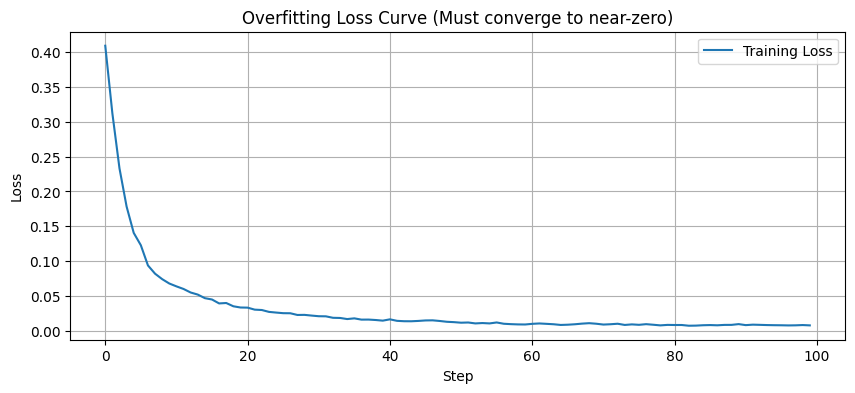

In [5]:
optimizer = optim.AdamW(model.parameters(), lr=0.005)
losses = []

print("\n Starting Overfit Test...")
model.train()
for step in range(100):
    optimizer.zero_grad()
    
    # Forward pass
    # The model calculates loss internally based on the inputs (autoregressive)
    outputs = model(context=inputs, 
                    site_coords=site_coords,
                    variate_ids=variate_ids,
                    channel_mask=id_mask,
                    has_coords=has_coords,)
    
    # Retrieve the loss
    # If your DeepWindOutput.loss already includes the MoE aux_loss, use it directly.
    # Otherwise, you might need: loss = outputs.loss + 0.01 * backbone_aux_loss
    loss = outputs.loss
        
    # Backward pass
    loss.backward()
    
    # Clip gradients to prevent explosion (common in transformers)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    
    optimizer.step()
    
    losses.append(loss.item())
    
    if step % 10 == 0:
        print(f"Step {step:03d} | Loss: {loss.item():.6f}")

# --- 5. Visualization & Verification ---

# A. Plot Loss Curve
plt.figure(figsize=(10, 4))
plt.plot(losses, label="Training Loss")
plt.title("Overfitting Loss Curve (Must converge to near-zero)")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

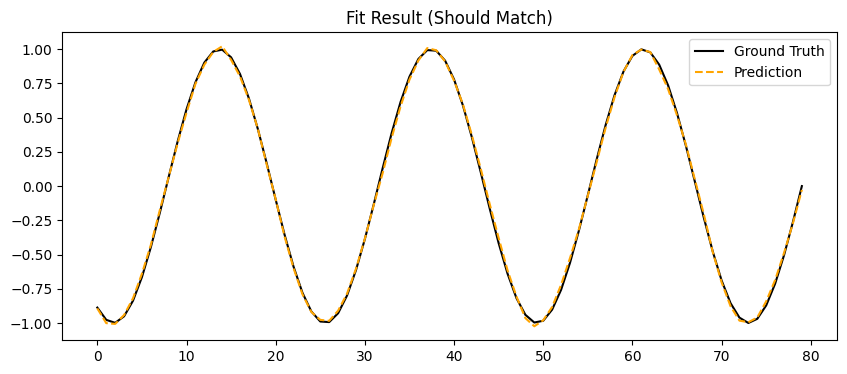

TEST PAST


In [15]:
model.eval()
with torch.no_grad():

    outputs = model(context=inputs, 
                    site_coords=site_coords,
                    variate_ids=variate_ids,
                    channel_mask=id_mask,
                    has_coords=has_coords,
                    output_router_logits=True)

    raw_preds = outputs.denorm_quantile_preds
    sorted_preds, _ = torch.sort(raw_preds, dim=-1)
    median_idx = sorted_preds.shape[-1] // 2
    median_preds = sorted_preds[..., median_idx]

    gt = inputs[0, 0, config.input_patch_size:].cpu().numpy()
    pd = median_preds[0, 0, :-config.input_patch_size].cpu().numpy()

plt.figure(figsize=(10, 4))
plt.plot(gt, label="Ground Truth", color='black')
plt.plot(pd, label="Prediction", linestyle='--', color='orange')
plt.title("Fit Result (Should Match)")
plt.legend()
plt.show()

if losses[-1] < 0.1:
    print("TEST PAST")
else:
    print("TEST FAILURE")

In [ ]:
outputs.keys()        

odict_keys(['denorm_quantile_preds', 'loc_scale', 'scaled_context', 'all_ffn_details'])

🔍 Analyzing MoE Layers: [0, 1] (Total Layers: 2)


C:\Users\HexianWang\AppData\Local\Temp\ipykernel_21424\4036784301.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(range(num_experts)), y=usage, ax=axes[i], palette="viridis")
C:\Users\HexianWang\AppData\Local\Temp\ipykernel_21424\4036784301.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(range(num_experts)), y=usage, ax=axes[i], palette="viridis")


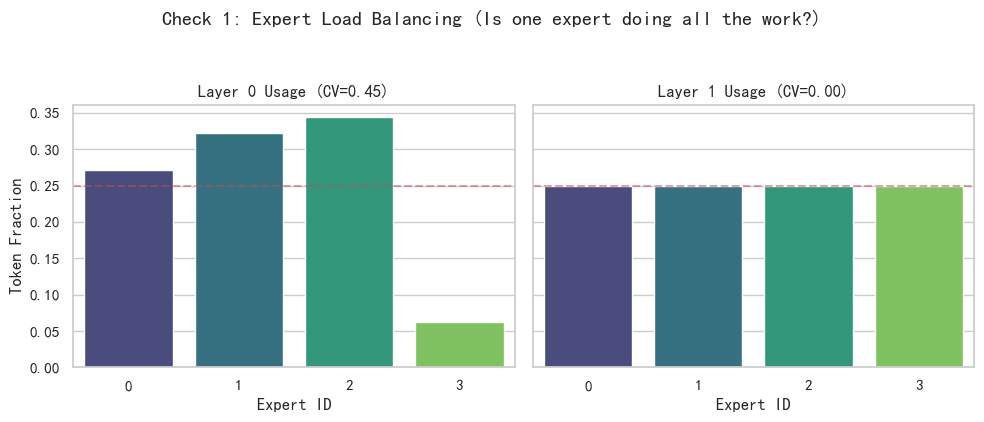

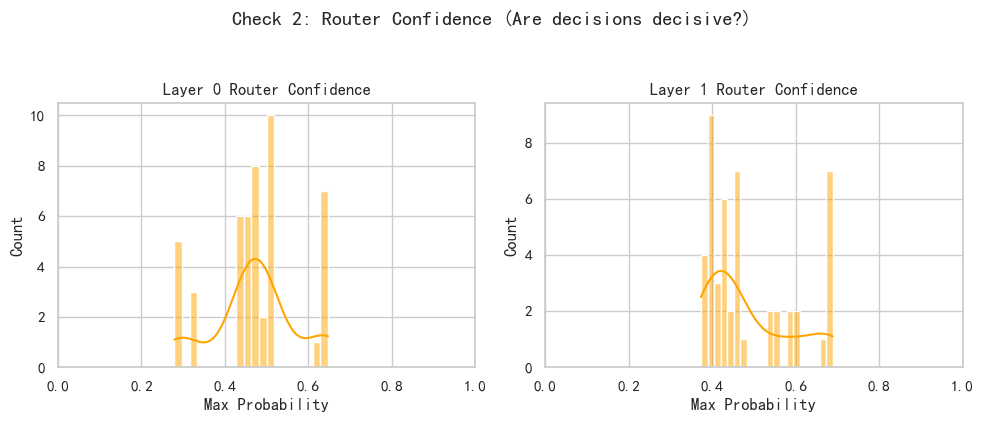


Check 3: Expert Activation Heatmap (Time vs Experts)


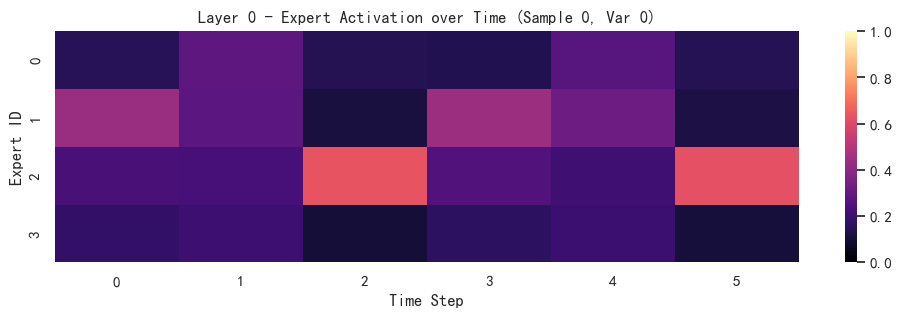

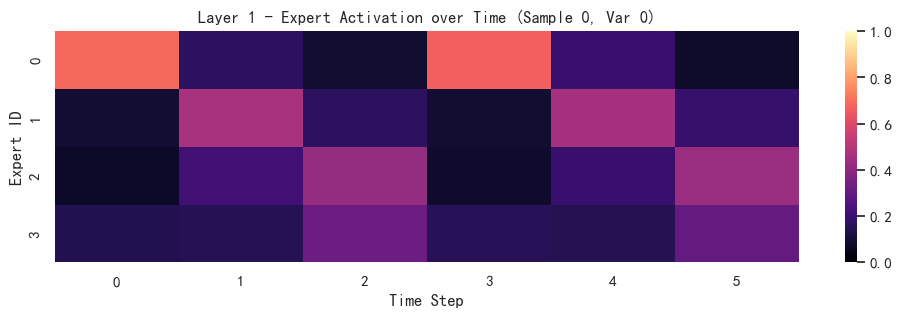


Check 4: Expert Co-occurrence Matrix (Layer 0)


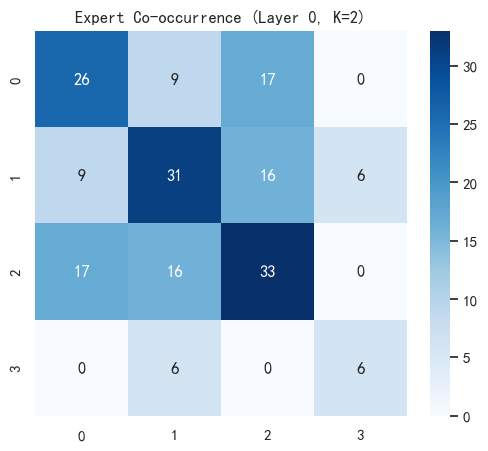

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False

def analyze_moe_behavior(all_ffn_details, layer_indices=None):
    """
    Comprehensive Analysis of MoE Layers.
    
    Args:
        all_ffn_details: Tuple of FeedForwardOutput objects from the model output.
        layer_indices: List of integers, specifying which layers to analyze. 
                       If None, analyzes first, middle, and last layers.
    """
    
    num_layers = len(all_ffn_details)
    if layer_indices is None:
        layer_indices = [0, num_layers // 2, num_layers - 1]
        # Remove duplicates and sort
        layer_indices = sorted(list(set(layer_indices)))
    
    print(f"🔍 Analyzing MoE Layers: {layer_indices} (Total Layers: {num_layers})")

    # =======================================================
    # 1. Load Balancing Analysis (专家负载均衡情况)
    # =======================================================
    # Goal: Check for "Expert Collapse". Ideally, usage should be somewhat balanced.
    
    fig, axes = plt.subplots(1, len(layer_indices), figsize=(5 * len(layer_indices), 4), sharey=True)
    if len(layer_indices) == 1: axes = [axes]

    for i, layer_idx in enumerate(layer_indices):
        details = all_ffn_details[layer_idx]
        
        # 'expert_usage' usually represents the fraction of tokens assigned to each expert
        # Shape: (Num_Experts,)
        usage = details.expert_usage.detach().cpu().numpy()
        num_experts = len(usage)
        
        # Calculate Coefficient of Variation (CV) to quantify imbalance
        # CV = std / mean. Lower is better (more balanced).
        cv = np.std(usage) / (np.mean(usage) + 1e-6)
        
        sns.barplot(x=list(range(num_experts)), y=usage, ax=axes[i], palette="viridis")
        axes[i].set_title(f"Layer {layer_idx} Usage (CV={cv:.2f})")
        axes[i].set_xlabel("Expert ID")
        if i == 0: axes[i].set_ylabel("Token Fraction")
        
        # Add a horizontal line for perfect balance
        axes[i].axhline(y=1.0/num_experts, color='r', linestyle='--', alpha=0.5, label="Ideal")

    plt.suptitle("Check 1: Expert Load Balancing (Is one expert doing all the work?)", y=1.05)
    plt.tight_layout()
    plt.show()

    # =======================================================
    # 2. Router Confidence Analysis 
    # =======================================================
    # Goal: Is the router confident (prob near 1.0) or confused (prob near 1/E)?
    # We use 'gate_probs' for this.
    
    fig, axes = plt.subplots(1, len(layer_indices), figsize=(5 * len(layer_indices), 4))
    if len(layer_indices) == 1: axes = [axes]

    for i, layer_idx in enumerate(layer_indices):
        details = all_ffn_details[layer_idx]
        
        # gate_probs Shape: [Batch, Variate, Time, Experts]
        # We take the MAX probability for each token (how confident was the router?)
        probs = details.gate_probs.detach().cpu()
        max_probs, _ = torch.max(probs, dim=-1) # [Batch, Variate, Time]
        
        # Flatten for histogram
        flat_max_probs = max_probs.flatten().numpy()
        
        sns.histplot(flat_max_probs, bins=20, kde=True, ax=axes[i], color="orange")
        axes[i].set_title(f"Layer {layer_idx} Router Confidence")
        axes[i].set_xlabel("Max Probability")
        axes[i].set_xlim(0, 1.0)
    
    plt.suptitle("Check 2: Router Confidence (Are decisions decisive?)", y=1.05)
    plt.tight_layout()
    plt.show()

    # =======================================================
    # 3. Spatiotemporal Expert Activation (时空分布热力图)
    # =======================================================
    # Goal: See which experts handle which time steps.
    # We visualize Sample 0, Variate 0.
    
    print("\nCheck 3: Expert Activation Heatmap (Time vs Experts)")
    
    for layer_idx in layer_indices:
        details = all_ffn_details[layer_idx]
        
        # Shape: [Batch, Variate, Time, Experts]
        # Take Sample 0, Variate 0
        # Result: [Time, Experts]
        router_map = details.gate_probs[0, 0, :, :].detach().cpu().numpy()
        
        # Transpose for easier viewing: [Experts, Time]
        # X-axis: Time, Y-axis: Expert ID
        plt.figure(figsize=(12, 3))
        sns.heatmap(router_map.T, cmap="magma", vmin=0, vmax=1.0)
        plt.title(f"Layer {layer_idx} - Expert Activation over Time (Sample 0, Var 0)")
        plt.xlabel("Time Step")
        plt.ylabel("Expert ID")
        plt.show()
        
    # =======================================================
    # 4. Expert Co-occurrence (专家协同关系 - 进阶)
    # =======================================================
    # If Top-K > 1, which experts are often selected together?
    # Using 'selected_experts' [Batch, Variate, Time, K]
    
    K = all_ffn_details[0].selected_experts.shape[-1]
    if K > 1:
        print("\nCheck 4: Expert Co-occurrence Matrix (Layer 0)")
        details = all_ffn_details[0]
        # Flatten: [Total_Tokens, K]
        selections = details.selected_experts.reshape(-1, K).detach().cpu().numpy()
        num_experts = details.gate_probs.shape[-1]
        
        co_matrix = np.zeros((num_experts, num_experts))
        
        # Naive loop for co-occurrence (fast enough for small batches)
        for row in selections:
            # row contains indices of experts selected for one token
            for e1 in row:
                for e2 in row:
                    co_matrix[e1, e2] += 1
        
        # Normalize (Optional, making diagonals 1)
        # co_matrix = co_matrix / co_matrix.max()
        
        plt.figure(figsize=(6, 5))
        sns.heatmap(co_matrix, cmap="Blues", annot=True, fmt=".0f")
        plt.title(f"Expert Co-occurrence (Layer 0, K={K})")
        plt.show()

# --- Run the Analysis ---
# Assuming 'outputs' is your DeepWindOutput from the previous step
if outputs.all_ffn_details is not None:
    analyze_moe_behavior(outputs.all_ffn_details)
else:
    print("❌ Error: all_ffn_details is None. Did you set output_moe_details=True?")

In [2]:
# Dataset test
from pathlib import Path
from torch.utils.data import DataLoader
from src.data.datasets import DeepWindTestDataset, DeepWindTrainDataset, DeepWindValidDataset

TRAIN_ROOT_NPY_PATH = Path("E:/timeseries-forecasting/project-12-14/deepwind/data/train_data")
VALID_NPY_FILE_PATH = Path("E:/journal_paper_2/project_12_16/deepwind/data/test_data")
TEST_NPY_FILE_PATH = Path("E:/timeseries-forecasting/project-12-14/deepwind/data/test_data/0.npy")
META_DATA_PATH = Path("E:/timeseries-forecasting/project-12-14/deepwind/test/train_metadata.csv")

In [ ]:
train_dataset = DeepWindTrainDataset(TRAIN_ROOT_NPY_PATH, META_DATA_PATH)
train_loader = DataLoader(train_dataset, batch_size=2)

batch = next(iter(train_loader))
print(batch.keys())
print(batch["context"].shape)
print(batch["variate_ids"])
print(batch["channel_mask"])
print(batch["site_coords"])
print(batch["has_coords"])

[WindNPYWindowDataset] Found 1 npy files in E:\timeseries-forecasting\project-12-14\deepwind\data\train_data
[DeepWindTrainDataset] Loading metadata from E:\timeseries-forecasting\project-12-14\deepwind\test\train_metadata.csv...
[DeepWindTrainDataset] Loaded metadata for 127455 sites.
dict_keys(['context', 'variate_ids', 'channel_mask', 'site_coords', 'has_coords'])
torch.Size([2, 6, 8192])
tensor([[ 0,  1,  2,  4,  6, 10],
        [ 0,  1,  2,  4,  6, 10]])
tensor([[1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 0.]])
tensor([[0., 0.],
        [0., 0.]])
tensor([[0.],
        [0.]])


In [46]:
test_dataset = DeepWindTestDataset(TEST_NPY_FILE_PATH, META_DATA_PATH, context_length=8192, prediction_length=64)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)
test_batch = next(iter(test_loader))

print(test_batch.keys())
print(test_batch["context"].shape)
print(test_batch["target"].shape)
print(test_batch["variate_ids"])
print(test_batch["channel_mask"])
print(test_batch["site_coords"])
print(test_batch["has_coords"])

[DeepWindTestDataset] Final Split: TEST (adjusted) | Range: [589132, 736416) | Total Time: 736416
dict_keys(['context', 'target', 'variate_ids', 'channel_mask', 'site_coords', 'has_coords'])
torch.Size([2, 6, 8192])
torch.Size([2, 6, 64])
tensor([[0, 1, 2, 3, 4, 5],
        [0, 1, 2, 3, 4, 5]])
tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])
tensor([[-117.1473,   23.5104],
        [-117.1473,   23.5104]])
tensor([[1.],
        [1.]])


In [3]:
valid_dataset = DeepWindValidDataset(VALID_NPY_FILE_PATH, META_DATA_PATH, context_length=8192)
valid_loader = DataLoader(valid_dataset, batch_size=2, shuffle=False)
valid_batch = next(iter(valid_loader))

print(valid_batch.keys())
print(valid_batch["context"].shape)
print(valid_batch["variate_ids"])
print(valid_batch["channel_mask"])
print(valid_batch["site_coords"]) 
print(valid_batch["has_coords"]) 

dict_keys(['context', 'variate_ids', 'channel_mask', 'site_coords', 'has_coords'])
torch.Size([1, 6, 8192])
tensor([[0, 1, 2, 4, 5, 6]])
tensor([[1., 1., 1., 1., 1., 1.]])
tensor([[0., 0.]])
tensor([[0.]])
